# Transfer Learning

-  Taking the patterns (also called weights) another model has learned from another problem and using them for our own problem.

- There are two main benefits to using transfer learning:

    - Can leverage an existing neural network architecture proven to work on problems similar to our own.
    - Can leverage a working neural network architecture which has already learned patterns on similar data to our own. This often results in achieving great results with less custom data.

- Transfer Learning Types:

    - **"As is"** transfer learning is when you take a pretrained model as it is and apply it to your task without any changes.
        - For example, many computer vision models are pretrained on the ImageNet dataset which contains 1000 different classes of images. This means passing a single image to this model will produce 1000 different prediction probability values (1 for each class).

        - This is helpful if you have 1000 classes of image you'd like to classify and they're all the same as the ImageNet classes, however, it's not helpful if you want to classify only a small subset of classes (such as 10 different kinds of food). Model's with "/classification" in their name on TensorFlow Hub provide this kind of functionality.

    - **"Feature extraction"** transfer learning is when you take the underlying patterns (also called weights) a pretrained model has learned and adjust its outputs to be more suited to your problem.
        - For example, say the pretrained model you were using had 236 different layers (EfficientNetB0 has 236 layers), but the top layer outputs 1000 classes because it was pretrained on ImageNet. To adjust this to your own problem, you might remove the original activation layer and replace it with your own but with the right number of output classes. The important part here is that only the top few layers become trainable, the rest remain frozen.

        - This way all the underlying patterns remain in the rest of the layers and you can utilise them for your own problem. This kind of transfer learning is very helpful when your data is similar to the data a model has been pretrained on.

    - **"Fine-tuning transfer"** learning is when you take the underlying patterns (also called weights) of a pretrained model and adjust (fine-tune) them to your own problem.

        - This usually means training some, many or all of the layers in the pretrained model. This is useful when you've got a large dataset (e.g. 100+ images per class) where your data is slightly different to the data the original model was trained on.
        - A common workflow is to "freeze" all of the learned patterns in the bottom layers of a pretrained model so they're untrainable. And then train the top 2-3 layers of so the pretrained model can adjust its outputs to your custom data (feature extraction).
        <br>**"After you've trained the top 2-3 layers, you can then gradually "unfreeze" more and more layers and run the training process on your own data to further fine-tune the pretrained model."**

## PT.1 - Feature Extraction

In [1]:
# This MUST be set BEFORE importing TensorFlow
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import pathlib
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow_hub as hub

2026-02-02 21:52:50.484003: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data

In [2]:
IMAGE_SHAPE = (224,224)
BATCH_SIZE = 32

In [3]:
# Directories
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

In [4]:
# Classes
import pathlib
import numpy as np
data_dir= pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
class_names

array(['chicken_curry', 'chicken_wings', 'fried_rice', 'grilled_salmon',
       'hamburger', 'ice_cream', 'pizza', 'ramen', 'steak', 'sushi'],
      dtype='<U14')

## Data Loaders

In [5]:
train_datagen = ImageDataGenerator(rescale=1/255.)

test_datagen = ImageDataGenerator(rescale=1/255.)

print("Training Images:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=IMAGE_SHAPE,
                                               batch_size=BATCH_SIZE,
                                               class_mode='categorical')
print("Testing Images:")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=IMAGE_SHAPE,
                                             batch_size=BATCH_SIZE,
                                             class_mode='categorical')

Training Images:
Found 7500 images belonging to 10 classes.
Testing Images:
Found 2500 images belonging to 10 classes.


---

## Callbacks

- Callbacks are extra functionality you can add to your models to be performed during or after training. Some of the most popular callbacks include:

   - **Experiment tracking with TensorBoard** - log the performance of multiple models and then view and compare these models in a visual way on TensorBoard (a dashboard for inspecting neural network parameters). Helpful to compare the results of different models on your data.
   - **Model checkpointing** - save your model as it trains so you can stop training if needed and come back to continue off where you left. Helpful if training takes a long time and can't be done in one sitting.
   - **Early stopping** - leave your model training for an arbitrary amount of time and have it stop training automatically when it ceases to improve. Helpful when you've got a large dataset and don't know how long training will take.

### TensorFlow Callback Classes

| Callback Class            | Description (Function & Use Case)                                                                                                                                                                         |                                                              |                               |
| ------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------ | ----------------------------- |
| **Callback**              | Base class for building custom callbacks by overriding methods like `on_epoch_end` or `on_batch_end`; used to implement custom logic during training such as logging, debugging, or early stopping rules. |                                                              |                               |
| **ModelCheckpoint**       | Saves the model or model weights at specific intervals or when a monitored metric improves; used to keep the best-performing model and prevent loss of training progress.                                 |                                                              |                               |
| **EarlyStopping**         | Monitors a metric and stops training when it stops improving for a defined number of epochs; used to prevent overfitting and reduce unnecessary training time.                                            |                                                              |                               |
| **LearningRateScheduler** | Updates the learning rate according to a user-defined schedule; used to control learning rate dynamics and improve convergence.                                                                           |                                                              |                               |
| **ReduceLROnPlateau**     | Reduces the learning rate when a monitored metric has stopped improving; used to fine-tune training when performance plateaus.                                                                            |                                                              |                               |
| **TensorBoard**           | Logs metrics, model graphs, histograms, and images for visualization in TensorBoard; used for monitoring, debugging, and analyzing training behavior.                                                     |                                                              |                               |
| **CSVLogger**             | Records training metrics at the end of each epoch into a CSV file; used for saving training history for later analysis or reporting.                                                                      |                                                              |                               |
| **TerminateOnNaN**        | Stops training immediately if NaN or infinite values appear in the loss; used to handle numerical instability safely.                                                                                     |                                                              |                               |
| **ProgbarLogger**         | Displays a progress bar and training metrics during model fitting; used to provide real-time visual feedback of training progress.                                                                        |                                                              |                               |
| **BackupAndRestore**      | Saves and restores the full training state automatically; used for fault-tolerant training in long-running or interrupted jobs.                                                                           |                                                              |                               |
| **LambdaCallback**        | Allows defining callback behavior using simple Python lambda functions; used for quick and lightweight custom callback actions.                                                                           |                                                              |                               |
| **RemoteMonitor**         | Sends training metrics to a remote server using HTTP requests; used for monitoring training from external systems.                                                                                        | Sends training metrics to a remote server via HTTP requests. | Monitoring training remotely. |

### Notes

* Callbacks are passed to the `model.fit()` function using the `callbacks` parameter.
* Multiple callbacks can be used together during training.
* Callbacks are especially useful for **automation, monitoring, optimization, and safety** during deep learning experiments.

In [6]:
# Create tensorboard callback (functionized because need to create a new one for each model)
import datetime
def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(
      log_dir=log_dir
  )
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

'''
- Because you're likely to run multiple experiments, it's a good idea to be able to track them in some way.

- In our case, our function saves a model's performance logs to a directory named [dir_name]/[experiment_name]/[current_timestamp], where:

dir_name: is the overall logs directory
experiment_name: is the particular experiment
current_timestamp: is the time the experiment started based on Python's datetime.datetime().now()
'''

"\n- Because you're likely to run multiple experiments, it's a good idea to be able to track them in some way.\n\n- In our case, our function saves a model's performance logs to a directory named [dir_name]/[experiment_name]/[current_timestamp], where:\n\ndir_name: is the overall logs directory\nexperiment_name: is the particular experiment\ncurrent_timestamp: is the time the experiment started based on Python's datetime.datetime().now()\n"

---

## TensorFlow Hub

* Steps:
    1. Go to tfhub.dev.
    2. Choose your problem domain, e.g. "Image" (we're using food images).
    3. Select your TF version, which in our case is TF2.
    4. Remove all "Problem domanin" filters except for the problem you're working on.
    5. The models listed are all models which could potentially be used for your problem.


### Create a model function

In [7]:
def create_model(model_url, num_classes=10, img_shape=(224, 224, 3)):
    # Create model using Sequential API with a workaround for TensorFlow Hub compatibility
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=img_shape),
        hub.KerasLayer(model_url, trainable=False, name='feature_extractor'),
        tf.keras.layers.Dense(num_classes, activation='softmax', name='Output')
    ])

    return model

---

## Trying ResNet model

In [8]:
# Pre-trained Model Link

resnet = "https://tfhub.dev/google/imagenet/resnet_v2_101/feature_vector/5"

In [9]:
# Creating Model

resnet_model = create_model(resnet, 10)

I0000 00:00:1770061988.142350  101676 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
# Model Summary

resnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extractor (KerasLa  (None, 2048)              42626560  
 yer)                                                            
                                                                 
 Output (Dense)              (None, 10)                20490     
                                                                 
Total params: 42647050 (162.69 MB)
Trainable params: 20490 (80.04 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________


In [11]:
# Compiling Model

resnet_model.compile(metrics=['accuracy'],
                     optimizer=tf.keras.optimizers.Adam(),
                     loss='categorical_crossentropy')

In [12]:
# Fitting Model

hist = resnet_model.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data),
                        callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub",
                                                               experiment_name='ResNetV2')]
                        )

Saving TensorBoard log files to: tensorflow_hub/ResNetV2/20260202-215319
Epoch 1/5


2026-02-02 21:53:38.417199: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2026-02-02 21:53:41.530541: I external/local_xla/xla/service/service.cc:163] XLA service 0x7bc3f12eae60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-02 21:53:41.530622: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-02-02 21:53:41.576010: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770062022.009567  102049 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


235/235 [==============================] - 127s 452ms/step - loss: 0.8951 - accuracy: 0.7135 - val_loss: 0.5196 - val_accuracy: 0.8324
Epoch 2/5
235/235 [==============================] - 95s 405ms/step - loss: 0.5167 - accuracy: 0.8348 - val_loss: 0.4698 - val_accuracy: 0.8496
Epoch 3/5
235/235 [==============================] - 111s 473ms/step - loss: 0.4181 - accuracy: 0.8664 - val_loss: 0.4403 - val_accuracy: 0.8568
Epoch 4/5
235/235 [==============================] - 110s 476ms/step - loss: 0.3462 - accuracy: 0.8884 - val_loss: 0.4217 - val_accuracy: 0.8596
Epoch 5/5
235/235 [==============================] - 104s 441ms/step - loss: 0.2966 - accuracy: 0.9091 - val_loss: 0.4530 - val_accuracy: 0.8520


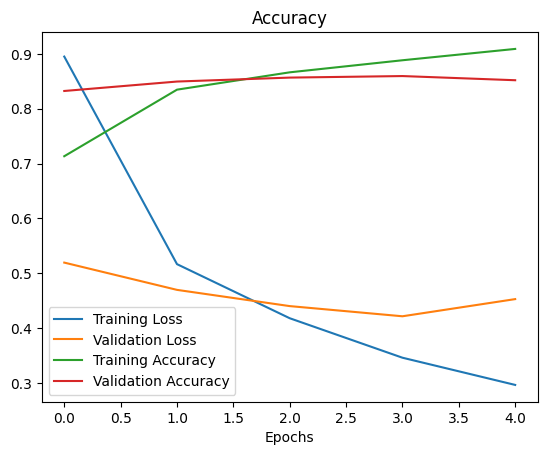

In [13]:
# plot loss curves

import matplotlib.pyplot as plt

def plot_loss_curves(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    epochs = range(len(history.history["loss"]))

    # plot loss
    plt.plot(epochs, loss, label="Training Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # plot accuracy
    plt.plot(epochs, accuracy, label="Training Accuracy")
    plt.plot(epochs, val_accuracy, label="Validation Accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

plot_loss_curves(hist)

---

## Trying EfficientNet V2

In [14]:
# Pre-trained Model Link

efficient = "https://www.kaggle.com/models/google/efficientnet-v2/TensorFlow2/imagenet1k-b0-classification/2"

In [15]:
# Creating Model

efficient_model = create_model(efficient, 10)

In [16]:
# Model Summary

efficient_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extractor (KerasLa  (None, 1000)              7200312   
 yer)                                                            
                                                                 
 Output (Dense)              (None, 10)                10010     
                                                                 
Total params: 7210322 (27.51 MB)
Trainable params: 10010 (39.10 KB)
Non-trainable params: 7200312 (27.47 MB)
_________________________________________________________________


In [17]:
# Compiling Model

efficient_model.compile(metrics=['accuracy'],
                        optimizer=tf.keras.optimizers.Adam(),
                        loss='categorical_crossentropy')

In [18]:
# Fitting Model

hist = efficient_model.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data),
                        callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub",
                                                               experiment_name='EfficientNetV2')]
                        )

Saving TensorBoard log files to: tensorflow_hub/EfficientNetV2/20260202-220241
Epoch 1/5
235/235 [==============================] - 134s 497ms/step - loss: 0.9698 - accuracy: 0.6859 - val_loss: 0.5750 - val_accuracy: 0.8036
Epoch 2/5
235/235 [==============================] - 117s 496ms/step - loss: 0.6403 - accuracy: 0.7903 - val_loss: 0.5310 - val_accuracy: 0.8248
Epoch 3/5
235/235 [==============================] - 89s 376ms/step - loss: 0.5686 - accuracy: 0.8121 - val_loss: 0.5024 - val_accuracy: 0.8280
Epoch 4/5
235/235 [==============================] - 99s 421ms/step - loss: 0.5254 - accuracy: 0.8285 - val_loss: 0.5018 - val_accuracy: 0.8368
Epoch 5/5
235/235 [==============================] - 106s 452ms/step - loss: 0.4937 - accuracy: 0.8357 - val_loss: 0.4875 - val_accuracy: 0.8408


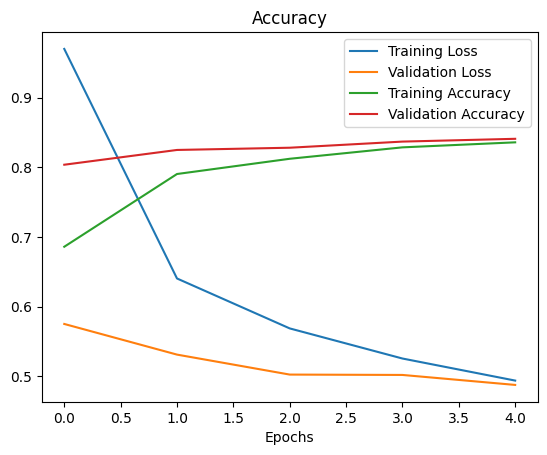

In [19]:
# plot loss and accuracy curves

plot_loss_curves(hist)

---

## Comparing between ResNet and EfficientNet using the Tensorboard Callback

In [ ]:
# Load TensorBoard extension in Jupyter
%load_ext tensorboard

# View logs locally
%tensorboard --logdir ./tensorflow_hub/

---